<img src=../figures/Brown_logo.svg width=50%>

## Agentic Data-Driven Design & Analysis of Structures & Materials

## From human-centric to agentic-centric data-driven design

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor, Brown University

### Elvis Aguero | <a href = "mailto: elvis_vera@brown.edu">elvis_vera@brown.edu</a>  | PhD candidate, Brown University

## **OPTION 1**. Run this notebook **locally in your computer** (needed for the agentic part)

1. Install [mamba](https://mamba.readthedocs.io/en/latest/installation/mamba-installation.html) (or conda) and [git](https://github.com/git-guides/install-git). Clone the course repository:
```
git clone https://github.com/bessagroup/3dasm_course
```
2. Create the environment for this short course (Python 3.11, JupyterLab 4 with the RISE slideshow extension, and f3dasm):
```
mamba create -n aescape_course python=3.11 jupyterlab=4 numpy scipy matplotlib pandas scikit-learn ipykernel ipywidgets requests
mamba activate aescape_course
pip install jupyterlab-rise "f3dasm[scipy]==2.4.0"
```
3. Install a coding agent. The agentic stages of Part 1 were run with [Claude Code](https://docs.anthropic.com/en/docs/claude-code), which needs a Claude subscription:
```
curl -fsSL https://claude.ai/install.sh | bash
claude
```
Log in once. Check it works with `claude -p "say ok"`.
4. Start JupyterLab from the `3dasm_course` folder and open `Lectures/short_course/aescape_course.ipynb`:
```
jupyter lab
```
To see the slides, press `Alt+R` (or the RISE button in the notebook toolbar). The slide fonts are small by default: zoom the browser to 150 to 175% with `Ctrl` and `+` before going full screen.
5. To run the agentic stages yourself: in a terminal, `cd Lectures/short_course/demo_car`, `mamba activate aescape_course`, `PYTHON=python bash reset.sh`, then `claude` and type the prompts shown in the slides.


## **OPTION 2**. Use **Google's Colab** (no installation, but only for the code cells of this notebook)

1. Go to https://colab.research.google.com and log in.
2. File > Open notebook > GitHub, paste https://github.com/bessagroup/3dasm_course, open `Lectures/short_course/aescape_course.ipynb`.
3. The code cells install `f3dasm` on first run. The agentic stages (the `claude` prompts) cannot run in Colab: they need a coding agent on your own machine and a clone of the repository (Option 1).


**Working draft.** Content ported verbatim from Elvis Aguero's draft Lectures 19.1, 19.2 and 19.3 (branch `agentic`, commit c96984b) on 2026-09-03, in his order, minus course scaffolding. Restructuring follows the outline in the plan.

In [ ]:
# Basic plotting tools needed in Python.

import matplotlib.pyplot as plt # import plotting tools to create figures
import numpy as np # import numpy to handle a lot of things!

# (retina figures disabled on purpose: large images trigger a Notebook 6 websocket bug)
plt.rcParams["figure.figsize"] = (8,4) # rescale figure size appropriately for slides

# To limit the number of rows to show in a dataframe, for presentation purposes:
import pandas as pd

pd.set_option('display.max_rows', 10)

In [ ]:
# Colab (or any machine without f3dasm): install it on first run, about 20 seconds.
try:
    import f3dasm
except ModuleNotFoundError:
    %pip install "f3dasm[scipy]==2.4.0" --quiet
    import f3dasm

from f3dasm import ExperimentData, datagenerator, create_sampler, Block
from f3dasm.design import Domain


# Part 1. From human-centric to agentic-centric data-driven processes

## The smallest problem I teach

A car at velocity $x$ stops after a distance $y$. The driver's reaction time $z$ is random.

$$y = z\,x + 0.1\,x^2, \qquad z \sim \mathcal{N}(1.5,\ 0.5^2)$$

<img src=../figures/reaction-braking-stopping.svg width=42% align="left">

We do not know this equation. We only get to measure stops. The task: predict $y$ for a new $x$, with honest uncertainty.

This is the first problem in my course and it stays with the students for eleven weeks. I use it here for one reason: nothing can hide in it. You will see the entire data-driven process on it, first done by a person, then done by agents, and you will be able to judge every step because you can do the algebra in your head. The true answer, which the process does not know, is that the mean is quadratic in velocity and the noise grows linearly with velocity.

## The data-driven process

<p align="center"><img src=../figures/data-driven-process.png width=50%></p>

Four stages, closed into a cycle: **design of experiments**, **data generation**, **machine learning**, **optimization**. Every engineering study we run follows this loop.

The user (human) decides what goes in each box. The software runs the boxes.

This figure is the whole method, and it is also the whole argument of the afternoon. Watch which of these boxes a person fills in and which ones a machine fills in. In 2019 the person filled all four. Today you will see agents fill two of them on this toy problem, and in Part 2, all four on a real one.

**Design of experiments** and **data generation**, the 2019 way: a person writes both.

Let's start by defining the **Design of experiments** (or Sampling) `Block`:

In [3]:
# Design of experiments, adapted from demo_car/make_data.py: the design space
# and a Sobol sequence of 60 velocities.
import numpy as np
from f3dasm import ExperimentData, create_sampler, datagenerator
from f3dasm.design import Domain

X_LOW, X_HIGH = 3.0, 83.0     # velocity range [m/s]
MU_Z, SD_Z = 1.5, 0.5         # reaction time z ~ N(1.5, 0.5^2)
N_TRAIN = 60
SEED_TRAIN = 123              # sampler seed for the training record
SEED_TRAIN_NOISE = 2019       # generator seed for the training record

domain = Domain()
domain.add_float("x", low=X_LOW, high=X_HIGH)

data = ExperimentData(domain=domain)
sampler = create_sampler("sobol_sampler", seed=SEED_TRAIN)
data = sampler.call(data, n_samples=N_TRAIN)
domain

Domain(input_space={'x': ContinuousParameter(lower_bound=3.0, upper_bound=83.0, log=False)}, output_space={})

**Note**: When the `Block` is just sampling by a Sobol sequence, `f3dasm` already has this predefined.

And now the **Data generation** `Block`:

In [4]:
# Data generation, adapted from demo_car/make_data.py: one draw of the reaction
# time per experiment, then the stopping distance. This is the physics.
rng = np.random.default_rng(SEED_TRAIN_NOISE)


@datagenerator(output_names=["y"])
def car(x: float) -> float:
    z = rng.normal(MU_Z, SD_Z)
    return float(z * x + 0.1 * x ** 2)


data = car.call(data, mode="sequential")
data.store("demo_car/data")          # the record, on disk

input_df, output_df = data.to_pandas()
print(input_df.join(output_df).head())

      x           y
0   3.0    5.231400
1  43.0  277.273153
2  63.0  462.585642
3  23.0   75.836729
4  33.0  144.306322


**Note**: This is also a simple `Block` for Data generation, but see that we had to define it ourselves. A more complex Data generation process could involve a simulator using a commercial FEM code or a research code using IGA, for example.

The data generator is the physics. In this toy it is one line. In Part 2 it is two Abaqus analyses that take an hour. The framework does not care; a row goes in, a row comes back with more columns.

**Machine learning**, the 2019 way: a person decides the model. For example: Quadratic least squares and constant noise.

In [5]:
# Machine learning, the 2019 way: the third block of the process, written by a person.
from f3dasm import Block
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

class QuadraticLeastSquares(Block):
    """A person decided: degree-2 least squares for the mean, one constant noise sd."""
    degree = 2

    def call(self, data, **kwargs):
        input_df, output_df = data.to_pandas()
        x = input_df["x"].to_numpy(dtype=float).reshape(-1, 1)
        y = output_df["y"].to_numpy(dtype=float)

        model = make_pipeline(                                       # features [1, x, x^2]
            PolynomialFeatures(degree=self.degree, include_bias=True),
            LinearRegression(fit_intercept=False))                   # least squares
        model.fit(x, y)
        resid = y - model.predict(x)
        sd_const = float(np.sqrt(resid @ resid / (len(y) - self.degree - 1)))
        self.coef, self.sd_const = model[-1].coef_, sd_const
        print(f"coefficients [1, x, x^2] = {np.array2string(self.coef, precision=4)}")
        print(f"constant residual sd     = {sd_const:.4f}")

        # f3dasm bookkeeping: reopen the rows, append the new columns
        @datagenerator(output_names=["y_pred_baseline", "sd_baseline", "_source_baseline"])
        def predict(x: float):
            return float(model.predict([[x]])[0]), sd_const, "baseline"

        return predict.call(data.mark_all("open"), mode="sequential")


We can now run the data-driven process. In this case, the data-driven process is very simple:

1. Read the data: previously collected by someone who observed many drivers stopping to avoid hitting the moose.
2. Train a simple machine learning model: a Quadratic Least Squares model with constant noise.
3. Store the updated data object

In [6]:
data = ExperimentData.from_file("demo_car/data")   # the block reads the record ...
ml_block = QuadraticLeastSquares()
data = ml_block.call(data)                         # ... and writes its predictions into it
data.store("demo_car/data")


coefficients [1, x, x^2] = [-0.4342  1.4196  0.1008]
constant residual sd     = 27.5632


This shows that we trained the model on the data.

We can now make predictions for unseen drivers. Very simple.

Now that the data-driven process ran, we can plot the results (code is hidden in the notes below):

In [7]:
# PLOTTING HELPER. Not part of the data-driven process.
# The dashed band is the GROUND TRUTH: we know it because we generated the data.
# The process never sees it; it is drawn only so the audience can judge the model.
def true_mean(x):
    return MU_Z * np.asarray(x) + 0.1 * np.asarray(x) ** 2

def true_sd(x):
    return SD_Z * np.asarray(x)

def plot_fit(data, mean_col, sd_col, title):
    input_df, output_df = data.to_pandas()
    x = input_df["x"].to_numpy(dtype=float); y = output_df["y"].to_numpy(dtype=float)
    order = np.argsort(x)
    mean = output_df[mean_col].to_numpy(dtype=float)[order]
    sd = output_df[sd_col].to_numpy(dtype=float)[order]
    grid = np.linspace(X_LOW, X_HIGH, 400)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(x, y, s=18, color="#333333", zorder=3, label="training data")
    ax.plot(x[order], mean, color="#1f77b4", lw=2, label="model mean")
    ax.fill_between(x[order], mean - 2 * sd, mean + 2 * sd, color="#1f77b4", alpha=0.20,
                    label="model $\\pm2$ sd")
    ax.plot(grid, true_mean(grid) + 2 * true_sd(grid), "k--", lw=1.4, label="GROUND TRUTH $\\pm2$ sd (sd = 0.5 x)")
    ax.plot(grid, true_mean(grid) - 2 * true_sd(grid), "k--", lw=1.4)
    ax.set_xlabel("speed x [m/s]"); ax.set_ylabel("stopping distance y [m]"); ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    return fig


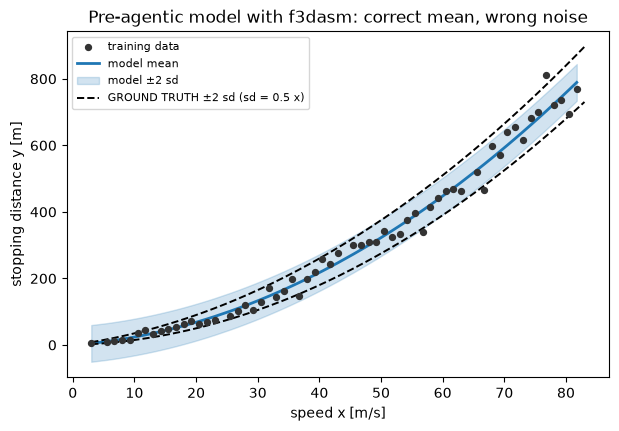

In [8]:
plot_fit(data, "y_pred_baseline", "sd_baseline", "Pre-agentic model with f3dasm: correct mean, wrong noise");


Good mean. Wrong uncertainty. The true band fans out with velocity; the model's band does not.

This is what a competent engineer writes in ten minutes, and it is wrong in the way that matters if you are certifying a braking system: the uncertainty at highway speed is badly underestimated. Every decision that produced this plot was mine: the model class, the noise assumption, the fact that I stopped here.

## The record

In [9]:
# the record, read back from disk
record = ExperimentData.from_file("demo_car/data")
record_input, record_output = record.to_pandas()
table = record_input.join(record_output)

print(list(table.columns))
print(table.head(3).to_string())

['x', 'y', 'y_pred_baseline', 'sd_baseline', '_source_baseline']
      x           y  y_pred_baseline  sd_baseline _source_baseline
0   3.0    5.231400         4.731874    27.563181         baseline
1  43.0  277.273153       246.975500    27.563181         baseline
2  63.0  462.585642       489.048124    27.563181         baseline


Every stop is a row. Every stage adds columns. **The file on disk is the truth about the study.**

Hold this picture. When the agents take over, the only thing that changes about this file is that it acquires columns saying who wrote what.

## What you just saw, named

<p align="center"><img src=../figures/f3dasm_carstoppingdistance_line.svg width=85%></p>

Our framework: **f**ramework for **d**ata-**d**riven **d**esign and **a**nalysis of **s**tructures and **m**aterials (`f3dasm`).

A design space is a `Domain`. Designs and results are rows of one `ExperimentData` record. Each stage is a `Block` that reads the record and writes to it. The record lives on disk as plain files.

Every object you saw has a name in our framework: the design space is a Domain, the rows are an ExperimentData record, each stage is a Block that reads the record and writes to it. I name them now, after you saw them work, because the agents will use exactly these names.

## What a person decided, and what software executed (toy version)

| A person decided | Software executed |
|---|---|
| Which velocities to measure, and how many | Drawing the Sobol sequence |
| That the mean is a quadratic | Least squares |
| That the noise is constant | Computing one residual variance |
| That this model is good enough | Saving the record |

Three of the four decisions are wrong or unexamined. Nothing in the process would ever tell us.

This is the slide I want you to photograph. Everything on the right, f3dasm automates well. Everything on the left took a person, and it was done once, and two of those decisions are quietly wrong. The human-centric process is an execution engine for human decisions, good or bad.

## Making it agentic. What you actually write.

```
demo_car/
  CLAUDE.md               the rules of the house, read by every agent
  .claude/agents/
    modeler.md            one agent: owns the machine learning block
    selector.md           one agent: owns model selection, may not touch the model
  data/                   the record you just saw
  make_data.py            your design of experiments and data generation
  baseline.py             your 2019 model
```

Three text files. No new framework, no API, no server. Your subscription to a coding agent runs it.

The folder is the unit of work. The agent is started inside it, reads the rules from it, and may not act outside it. The prompt never mentions paths; the rules do.

This is the entire transformation from the user's side. I did not write a line of modelling code for what follows. I wrote rules and roles, in English, and typed three sentences. Everything else in this part was produced by the agents and is in the record.

## The rules of the house (CLAUDE.md)

```markdown
1. **Numbers only from tools.** Every number you or a subagent reports must
   have been printed by code that ran. Never state a fitted value you did not
   print. If you did not run it, you do not know it.
2. **Everything into the record.** Results live as output columns of an f3dasm
   `ExperimentData`, not in loose `.npy`, `.json` or `.txt` files.
...
  the model selection goes to `selector`. Do not implement, re-fit or "just
  quickly check" the model yourself in that case, and do not do the selector's
  scoring for it. Run them in that order, then summarise their reports back to
  Miguel — what they changed, why, and the numbers they printed.
```

**The agent decides and wires. The tool computes. The record remembers.**

These rules are the same rules the large system in Part 2 enforces with code. Here they are instructions, and you will see they were followed. The line in bold is the one-sentence version of this whole part.

## The two roles (agent files)

<table style="width:100%; font-size:52%">
<tr><th width="50%"><code>.claude/agents/modeler.md</code></th><th width="50%"><code>.claude/agents/selector.md</code></th></tr>
<tr>
<td valign="top"><pre>
name: modeler
description: Owns the machine-learning model for the car
  stopping-distance record. Use when the model class has to
  change &mdash; for example when the baseline's constant-noise
  assumption is wrong. Implements an f3dasm Block, runs it,
  writes predictions into the record. Never scores itself on
  held-out data.

- You may **read** `data/`, `make_data.py`, `baseline.py`,
  `CLAUDE.md`, and anything already in `blocks/`.
- You may **write** only inside `blocks/`, and into the
  f3dasm record via f3dasm itself.
- **There is no held-out data, and you must not create any.**
</pre></td>
<td valign="top"><pre>
name: selector
description: Owns model selection for the car stopping-distance
  problem, the Lecture 18 way. Use after a model class exists
  and its hyperparameters need to be chosen. Creates its own
  held-out record, enumerates the candidate grid as an
  ExperimentData, scores it, and refits the winner. Never
  edits the model.

- You may **read** everything, including `blocks/`.
- You may **not** edit, rewrite, patch or "fix" anything in
  `blocks/`.
- You may write a scoring script (put it at the top level,
  e.g. `select_model.py`), records, and figures.

**Training error is forbidden as a score.** So is any number
computed on `data/`.
</pre></td>
</tr>
</table>

An agent is a system prompt, a tool list, and a report format. That is all. Read the "may not" lines: they are the reason there are two agents and not one, and I will come back to that.

Full excerpts:

modeler.md, after the "must not create any" line:
  `data/` is the only record that exists. Do not run
  `make_data.py`. Do not invent a test split. Judging your
  model is somebody else's job, and that separation is the
  whole point: a model that grades its own homework has not
  been graded.

  Every number you report must have been printed by code you
  ran.

selector.md, the two lines above and inside the "may not" bullet:
  You own model selection, and nothing else. You are the judge,
  not the author.

  If the model has a bug, say so in your report and
  stop; do not repair it. A judge who edits the thing being
  judged is not a judge.

## Who does what

| The user (you) | The agents (automatic) | What comes back |
|---|---|---|
| Writes the rules and the two roles, once | Read the folder, the record, the baseline | A report per agent: what changed, why, the numbers it printed |
| Types one sentence per stage | Write code into `blocks/`, run it, write results into the record | New columns in the record, with a provenance stamp |
| Reads the reports and the record | Never guess a number; every value comes from a tool run | Figures regenerated from the record |
| Decides whether to believe it | Stop and report | The reproduction notebook |

Three columns, and I want you to notice that the left one is short and the middle one is long. That is the shift. My work moved to the first and last rows: I write the constitution, and I review. The agents do the middle, and the record is how the middle becomes checkable.

## Stage 1. Change the model. One agent, no workflow.

In [ ]:
# Stage 1, typed into Claude Code inside demo_car/ (uncomment to run; needs Claude Code and the repo):
# !claude -p "The baseline in baseline.py fits the mean but assumes constant noise, and the data clearly does not. Change the model."

What it did, in 2 min 50 s: wrote a Bayesian linear regression with a log-noise polynomial in $x$ as an f3dasm Block, fitted it by type-II maximum likelihood, wrote predictions and standard deviations into the record.

<img src=demo_car/recorded/model.png width=55%>

fitted noise sd grows from 5.8 to 61 across the velocity range; the truth is $0.5x$.

One session, one instruction, no agents anywhere. For a well-posed change inside one module, this is all you need, and an agentic workflow would be overhead. Notice what the agent did not do: it did not invent numbers. Every value on this slide was printed by code it ran. That rule is in the folder's instruction file and it is the same rule the big system enforces.

## What the modeler reported

<pre style="font-size:46%; white-space:pre-wrap">
### What I changed
Wrote `blocks/hetero_blr.py`, a new f3dasm `Block` (`HeteroBLR`) that replaces the baseline's degree-2 least squares + one constant noise number with a heteroscedastic Bayesian linear regression:
- Mean: polynomial of degree `d_mean` in `t = x / x_scale`.
- Noise: `sd(x) = exp(c_0 + c_1 t + ... + c_{d_noise} t**d_noise)` ...
### Why
The baseline's mean is fine but its single constant residual sd cannot match the truth `sd[y|x] = 0.5x`, which grows roughly 28x from the low to high end of the speed range. A heteroscedastic noise model lets the band fan out with speed instead of being one flat number, matching the true data-generating process. ...
### Numbers
All printed by `python blocks/hetero_blr.py` ...
  fitted log-noise coefficients c = [1.6683 2.4794]
    sd(x=3.0)  = 5.8005
    sd(x=83.0) = 63.2893
  wrote y_pred_hblr, sd_hblr, _source_modeler into data/
### Files touched
No held-out data was created, `make_data.py` was not run, and `baseline.py` was not edited or re-run.
</pre>

Every number in that report was printed by code the agent ran. That is a rule it was given, and you can check it against the record.

This is what an agent's output looks like. Not a chat, a report with a fixed shape. The shape is the point: I can read twenty of these in the time it takes to read one transcript, and I can check every number against the record.

## Stage 2. Select the hyperparameters. Same session.

In [ ]:
# Stage 2, same session (uncomment to run):
# !claude -p "Now select the model's hyperparameters properly and show me the record." --resume <session>

What it did, in 2 min 13 s: created a held-out set of 200 stops, enumerated twelve candidate models as rows of an f3dasm record, scored each by held-out log predictive density, refit the winner.

<table style="width:100%">
<tr>
<td width="47%" valign="top">
<table style="width:100%; font-size:62%">
<tr><th><code>d_mean</code></th><th><code>d_noise</code></th><th>held-out log predictive density</th><th>held-out MSE</th></tr>
<tr><td>1</td><td>0</td><td>-5.2978</td><td>2219.85</td></tr>
<tr><td>1</td><td>1</td><td>-5.9441</td><td>46991.04</td></tr>
<tr><td>1</td><td>2</td><td>-5.0479</td><td>3537.32</td></tr>
<tr><td>2</td><td>0</td><td>-4.5764</td><td>505.59</td></tr>
<tr><td>2</td><td>1</td><td>-4.2604</td><td>510.34</td></tr>
<tr><td><b>2</b></td><td><b>2</b></td><td><b>-4.2395</b></td><td><b>508.75</b></td></tr>
<tr><td>3</td><td>0</td><td>-4.5965</td><td>533.07</td></tr>
<tr><td>3</td><td>1</td><td>-4.2744</td><td>551.29</td></tr>
<tr><td>3</td><td>2</td><td>-5.6142</td><td>23731.08</td></tr>
<tr><td>4</td><td>0</td><td>-4.5922</td><td>525.50</td></tr>
<tr><td>4</td><td>1</td><td>-4.6840</td><td>899.07</td></tr>
<tr><td>4</td><td>2</td><td>-4.2489</td><td>530.45</td></tr>
</table>


MSE alone would not separate the noise models; three rows are failed optimizer runs the session flagged and left alone. Log predictive density does separate them: constant noise loses by a third of a nat. **Selecting on error alone would have re-selected the baseline's mistake.**

This is Lecture 18 of my course done by an agent: candidates as rows, a score block, a table. It did everything right, including making its own held-out data without being told. So why would anyone want more than one agent?

## Who checked it?

> ## "In this session I built the model, chose the score, created the held-out set, and picked the winner. Every step is in the record, but nobody other than me checked any of them."

The agent wrote that itself, at the end of stage 2, unprompted.

Read it aloud and pause. Every engineer in the room knows why the person who trains the model must not hold the test set. The argument for a second agent is not that two agents do more work. It is that one of them can be forbidden from touching what the other built.

## Stage 3. Two agents, separated by what they may touch.

In [ ]:
# Stage 3, after reset.sh (uncomment to run):
# !claude -p "The baseline in baseline.py fits the mean but assumes constant noise, and the data clearly does not. Use the modeler and selector subagents: modeler fixes the model, selector selects its hyperparameters properly. Then show me the record."

| | modeler | selector |
|---|---|---|
| may read | training record, baseline | training record, the model's code |
| may write | the model block, its predictions | the held-out record, the score table, the selection |
| may not | see held-out data (it does not exist yet) | edit the model |
| communicates through | the record | the record |

<p align="center"><img src=demo_car/recorded/selection.png width=58%></p>

The selector's twelve candidates, scored on the held-out set it created itself: held-out log predictive density, brighter is better, star on the winner.


Same winner, same conclusion, 5 min 33 s. **Nothing about the answer changed. What changed is that you can believe it.**

The selector creates the exam after the student has finished writing. It cannot change the student's work, and the student never saw the exam. Both write only to the record, so I can audit every number afterwards without reading either transcript. That is the entire justification for multiple agents in our work, and it is the same split you will see in the real system: the critic reads and cannot write; only the implementer evaluates designs. The first time I ran it with a larger model it took seven minutes; with a smaller model for the two workers, under five. The computation is seconds either way; the rest is agents reading and writing files.

## What the selector reported

<pre style="font-size:46%; white-space:pre-wrap">
### What I changed
- Created the held-out record `data_test/` via `python make_data.py --test --seed 456` (I did not edit `make_data.py`, only ran it).
- Wrote `select_model.py`: builds a hand-enumerated 12-row `Domain` grid (`d_mean` in {1,2,3,4} × `d_noise` in {0,1,2}), fits `HeteroBLR` (imported, unmodified) on `data/` for each candidate, scores each on `data_test/` with mean log predictive density (proper scoring rule) and MSE, ...
- Wrote `figures/selection.png`, a heatmap of log predictive density over the (d_mean, d_noise) grid with the winning cell starred.
- Did not touch or regenerate `figures/model.png` (that belongs to the modeler and was left as-is, mtime unchanged).
### Why
Selecting hyperparameters on training error would just reward complexity; scoring on a held-out record with a strictly proper rule (log predictive density) rewards a model for getting both the mean *and* the uncertainty right ...
### Numbers
Held-out record: `data_test/` ... n = 200 (random sampler, noise seed 457), `x` in [3.73, 82.99].
Winner: `d_mean=2, d_noise=2` (log_pred_density = -4.2395, mse = 508.7484).
Margin over the best constant-noise (`d_noise=0`) candidate (`d_mean=2, d_noise=0`, log_pred_density = -4.5764): **0.3369 nats** in favor of the heteroscedastic model ...
### Files touched
...
Not touched: `blocks/hetero_blr.py`, `baseline.py`, `make_data.py`, `figures/model.png`, `figures/baseline.png`.
</pre>

The selector never touched the model. It created the exam, graded twelve candidates, and named a winner it did not build.

Read the line where it says what it created and what it refused to do. That is separation of powers in an agent's own words.

## The record, at the end

<pre style="font-size:35%">
data/experiment_data  --  60 rows

columns:
['x', 'y', 'y_pred_baseline', 'sd_baseline', '_source_baseline', 'y_pred_hblr', 'sd_hblr', '_source_modeler', 'y_pred_selected', 'sd_selected', '_source_selected']

first 3 rows:
      x           y  y_pred_baseline  sd_baseline _source_baseline  y_pred_hblr    sd_hblr _source_modeler  y_pred_selected  sd_selected              _source_selected
0   3.0    5.231400         4.731874    27.563181         baseline     4.927050   6.603655         modeler         4.861615     4.907417  selector(d_mean=2,d_noise=2)
1  43.0  277.273153       246.975500    27.563181         baseline   246.809230  19.430386         modeler       246.883188    21.757295  selector(d_mean=2,d_noise=2)
2  63.0  462.585642       489.048124    27.563181         baseline   488.687577  35.409942         modeler       488.486448    36.586799  selector(d_mean=2,d_noise=2)
</pre>

Three writers, three provenance stamps, one file. A notebook regenerates every figure from this record alone, verified with every other file removed.

**The agent decides and wires. The tool computes. The record remembers.**

This line is the summary of Part 2. Hold it, because the real system is the same sentence with five agents and a cluster.

## The human at the end: review

The run is over. Nothing has been believed yet. What I check, in order:

1. **Did every number come from a tool?** Reports against the record. Any number that is not in the record is not a result.
2. **Was the score honest?** Held-out data, created by someone who did not build the model. Training error is not a score.
3. **Does the model make physical sense?** Here: noise growing with speed is what physics says. A model that fit better and said otherwise would be wrong.
4. **Does it reproduce?** The notebook regenerates every figure from the record alone.
5. **What did the agents not do?** Reading the reports for what is absent is the hardest part and the one I cannot delegate.

This is the part people skip when they demo agents, and it is the part that matters. At the current state of the art, the human review is not optional. What changed is what I review: not code, but evidence. The five questions are the same five I ask of a student's report, and they are the same five the big system in Part 2 tries to ask of itself.

## What changed, and what did not

| A person decided | An agent decided | Software executed |
|---|---|---|
| Which velocities to measure | | Sobol sequence |
| | The mean is a quadratic, the noise grows with $x$ | Type-II maximum likelihood |
| | Which twelve candidates, which score, which held-out data | Twelve fits |
| That the modeler may not see the exam, and the selector may not touch the model | | Two agents, one record |

The person moved up one level: from choosing models to choosing who is allowed to decide what, and what counts as evidence.

Part 2: the same move, on a problem where one evaluation costs an hour and the design space has no fixed topology.

This is the summary of Part 1 and the bridge to Part 2. Notice the last row. I still decide, but what I decide is the constitution of the process, not its content. That is what I meant when I said I no longer code. And notice the first row: I still chose the experiment. In Part 2 the agents take that one too.

# Part 2. The same process at scale: a metamaterial, 2019 and 2026

<p align="center"><img src=../figures/bessa_baseline_native.gif width=62%></p>

**A brittle material that compresses to less than 20% of its height, and springs back.**

Polylactic acid (PLA). No plasticity, no damage. The vertical members buckle and coil.

This is the metamaterial we published in 2019. The material is ordinary 3D-printing plastic, which snaps if you bend it. The structure does not snap, it coils. We did not design it by intuition. We found it by sampling tens of thousands of geometries, simulating them, and letting machine learning tell us where the coilable ones live. That was the data-driven process in 2019. This afternoon is about what happened in 2026 when we pointed a team of AI agents at the same problem. Before I can show you that, you need to see how it was done the first time, with a person making every decision.

## The structure

<img src=../figures/supercompressible_schematic.png width=30% align="right">

Two rings, connected by three slender members, the longerons.

Geometry: bottom and top diameters $D_1$, $D_2$; height $P$; longeron cross-section area $A$, second moments $I_x$, $I_y$, torsional constant $J$. Material: Young's modulus $E$, shear modulus $G$.

The 2019 design question: **which geometries coil instead of collapsing, and among those, which carry the most load?**

**A person decided:** the topology. Three straight longerons, two rings, and nothing else was ever considered.

The topology is fixed: three straight longerons between two rings. Everything we vary is a proportion of this shape or a property of the cross-section. Remember that: the topology was never a variable. It will matter in Part 3.

## Coilable or not

<p align="center"><img src=../figures/supercompressible_process.png width=70%></p>

**Stage 1, linear buckling.** Compute the buckling modes of the perfect geometry. The first mode tells us whether this design coils or collapses.

**Stage 2, post-buckling (Riks).** Seed a small imperfection in the shape of the first mode, then compress. Record the load-displacement history and the strains.

**Coilable** means the mast compresses past 80% of its height without the load reversing. **Feasible** adds: no local strain above 2%, so PLA stays elastic, and the part can be printed.

**A person decided:** the success criteria. Coilable past 80%, local strain under 2%, printable.

Two finite element analyses per design, one after the other, both in Abaqus. The imperfection is not a design variable. Every printed part has one, so we draw its amplitude from a lognormal distribution fitted to measured parts, a hidden random variable. The 2% strain rule is our own yield criterion for PLA, from the paper's supporting information. Hold on to these three words, coilable, feasible, imperfection: the agents in Part 2 will be judged by exactly these rules.

## Seven numbers describe a design

$$\frac{D_1-D_2}{D_1},\ \frac{P}{D_1},\ \frac{I_x}{D_1^4},\ \frac{I_y}{D_1^4},\ \frac{J}{D_1^4},\ \frac{A}{D_1^2},\ \frac{G}{E}$$

| expression | name |
|---|---|
| $$(D_1-D_2)/D_1$$ | `ratio_top_diameter` |
| $$P/D_1$$ | `ratio_pitch` |
| $$I_x/D_1^4$$ | `ratio_Ixx` |
| $$I_y/D_1^4$$ | `ratio_Iyy` |
| $$J/D_1^4$$ | `ratio_J` |
| $$A/D_1^2$$ | `ratio_area` |
| $$G/E$$ | `ratio_shear_modulus` |

Everything is made dimensionless by $D_1$. A simpler 3-parameter version fixes a circular cross-section of diameter $d$: `ratio_d`, `ratio_top_diameter`, `ratio_pitch`.

**A person decided:** the variables and their bounds.

Seven dimensionless inputs, so the results transfer across scales. The three-parameter version is the one students use in my course. Seven dimensions is already enough that you cannot map the space by hand, which is why we needed data.

## The data-driven process

<p align="center"><img src=../figures/data-driven-process.png width=62%></p>

Four stages, closed into a cycle: **design of experiments**, **data generation**, **machine learning**, **optimization**.

In 2019, concretely: Sobol sampling of 50,000 designs in 7D and 1,000 in 3D; two Abaqus analyses per design on a cluster; a Gaussian process classifier for coilability and Gaussian process regression for the response; Bayesian optimization on top.

**A person decided:** the sampler, the simulator, the learner, the optimizer.

This picture is the whole method. Choose designs to evaluate, evaluate them, learn a model from the results, use the model to choose the next designs. Each stage in 2019 was a concrete tool. I want you to notice that every box in this figure is execution. Nothing in the figure decides which problem to solve, which variables to vary, or which criterion defines success. A person did that.

## What the data taught us

<p align="center"><img src=../figures/supercompressible_regression_classification.png width=85%></p>

A map of the design space: where designs coil, and how the response varies. Printed specimens confirmed the map.

The result: a PLA mast that compresses to less than a fifth of its height, reversibly. **Fragile became supercompressible.**

**A person decided:** which result was worth writing up.

The classifier draws the boundary between coilable and non-coilable regions; the regressor tells us the response inside the coilable region. We printed designs from the coilable region and tested them. That is the 2019 paper in one figure. Note the shape of the achievement: a better point inside a box we had defined.

## What a person decided, and what software executed

| A person decided | Software executed |
|---|---|
| The topology: three straight longerons, two rings | Sampling the seven-parameter box |
| Which seven parameters, and their bounds | Running every Abaqus job, retrying failures |
| That coilability is the thing to classify first | Fitting the classifier and the regressor |
| The 2% strain rule and the 80% compression target | Proposing the next designs |
| Which result was worth writing up | Keeping the record |

This is the slide I want you to photograph. Everything on the right, f3dasm automates well. Everything on the left took a person with a PhD in mechanics and months of time, and it was done once. When the idea changed, the left column started over. Compare this with the toy table from Part 1. Same shape, higher stakes, and in 2019 every row was mine.

## Static, and brittle

**Static.** The framework executes the study you defined. It never proposes a different one. The topology was never a variable because nobody wrote the code for a different topology.

**Brittle.** A new idea means a new parameterization, a new mesh script, a new post-processor, a new week. DRAFT (Miguel decides whether to say it): and the scripts rot; this week we found that our own course notebooks for this problem no longer ran on the current library version.

The data-driven process of 2019 was a very good way to answer a question a person had already asked.

I am not criticizing the method. It produced a result we are proud of. I am describing its boundary: it is an execution engine for human decisions. Every creative step is outside the loop.

## The question for the rest of the afternoon

**Can a system take the left column?** Propose the topology, choose the variables, decide what to classify, decide what counts as success, decide what is worth reporting.

And if it does, **how would we know whether to believe it?** Three requirements: it must not grade its own work; it must leave a record a stranger can audit; it must be stopped from confirming itself.

Part 2 is how we built a system with those three properties. Part 3 is what it did.

Those three requirements are the design principles of the framework Elvis built, and they are the backbone of Part 2. Keep the left column of the previous slide in your head, because at the end of Part 3 we will come back to it and mark which rows an agent actually took.

## The same three files, on the real problem

```
supercompressible-material/
  PROBLEM_STATEMENT.md   the brief: objective, feasibility rules, what counts as new
  config.yaml            model, budget (12 h), how a design is evaluated
  scripts/               the Abaqus pre- and post-processors a family needs
  runs/<timestamp>/      everything a run produced: the record, the hypotheses, the reviews
```

Same shape as the car folder. The brief is written the way a PI writes for a first-year student: the objective, the rules, and no babysitting.

From the brief itself, the objective and the three rules a design must satisfy:

<pre style="font-size:52%; white-space:pre-wrap">
Maximise the normalised peak compressive stress among feasible designs:

$$\sigma_{peak} = \frac{P_{max} \times 1000}{\dfrac{\pi D_1^2}{4} \times n_{longerons}} \quad \text{[kPa per longeron]}$$

**Feasibility, ALL criteria must hold for a design to count:**
1. Coilability: the mast reaches **max compressive strain &ge; 0.80** ...
2. The maximum local strain on the whole design, **up to the point where the mast reaches the criterion-2 compression threshold (mcs = 0.80)**, is **&le; 2%** ...
3. The design must be PLA-printable. This implies that the final design proposed must have enough predictive power to assert, beyond reasonable doubt, that the simulation is a faithful digital twin to the real physical system ...
</pre>

Elvis wrote the brief; I reviewed it. Notice that it is the Part 2 problem statement you already know, the 2019 rules, written for a machine to read. The difference from 2019 is one line that is NOT in this excerpt: the topology is no longer fixed. The agents may change the design representation.

## adda: five agents, one record

<p align="center"><img src=../figures/adda_flow.svg width=78%></p>

<sub>prototype package: a3dasm, by Elvis Aguero</sub>

**strategizer** decides what to try and delegates. **literature reviewer** answers from papers, never from memory. **data generator** turns a way of evaluating a design into a block the others can call. **implementer** runs sampling, learning and optimization against it. **critic** tries to break the result before it is accepted.

The graph, verbatim from the code:

<pre style="font-size:60%; white-space:pre-wrap">
strategizer (entry)  &rarr;  literature_reviewer
                     &rarr;  datagenerator
                     &rarr;  implementer
                     &rarr;  critic
datagenerator        &rarr;  literature_reviewer
implementer          &rarr;  literature_reviewer
</pre>

Six edges. The data generator and the implementer may ask the literature reviewer; nobody else talks to anybody. Only the strategizer assigns work.

Map this onto the toy. The modeler and the selector became five specialists, and the two rules from the car demo are still the whole design: the one who evaluates is not the one who judges, and everybody writes only to the record. The asymmetry is deliberate. If workers could hand each other work, the plan could change with no record of who decided.

## The decision table, filled by agents

| A person decided (2019) | Who takes it now |
|---|---|
| The topology | strategizer, from a hypothesis grounded by the literature reviewer |
| The variables and their bounds | strategizer, as a new parameterization; data generator builds the evaluator for it |
| Which criterion to classify first | fixed by the brief (the person, once) |
| The success rules: 80%, 2%, printable | fixed by the brief (the person, once) |
| Which result is worth reporting | strategizer proposes; critic decides whether it stands |

The person now decides the rules and the budget, and reads what comes back. Everything else moved.

Compare with the car table. In the toy the person still chose the experiment. Here even that is gone: the strategizer decides which family to explore next. What the person kept is the constitution: the brief, the feasibility rules, and the right to review.

## Earning trust, at scale

**Denied tools.** The critic's tool set is frozen in its class: `Read`, `Glob`, `Grep`, and read-only lookups into the record and the hypothesis list. Nothing that writes, nothing that executes. Only the implementer calls the evaluator, so every evaluation is stamped with who asked for it, when, and how long it took.

**A written charter.** Six numbered clauses, compiled verbatim into the two judging agents.

<pre style="font-size:56%; white-space:pre-wrap">
&sect;1  A hypothesis is ONE falsifiable claim carrying a registered prediction,
    the observable whose occurrence would refute the claim.

&sect;5  SUPPORTED is corroboration, not proof. It means the hypothesis survived
    at least one adequate attempt to refute it. You never "confirm" a
    hypothesis; you only fail to falsify it.
</pre>

**Two gates before a run may close.** The deliverable notebook must re-execute in a clean sandbox and reproduce its own headline number, six attempts at most. Then the critic answers `PASS`, `REVISE` or `REJECT`; three refusals and the run closes as unaudited.

These are the car demo's rules turned into code. The charter is text both judges share, so either can cite a clause by number and the other cannot renegotiate what falsification means. The reproduction gate runs before the critic is spent, so the critic never reviews a notebook that cannot run. I want to be honest about what the gates check: that the arithmetic reproduces, and that the claim survived an adversary. Not that the physics is right. That is still mine.

## What a run looks like

Across the framework's own ledger of **76 runs since June**: **63%** closed with a passed gate. On the four toy benchmark problems, the median run cost **about one dollar** and took **about 34 minutes**.

On the metamaterial, from the study's own record: **36 costed runs**, about **1,700 dollars** in model calls in total, **97 hypotheses**, of which **25** were genuinely new mechanisms and **55** refinements. One run on a 10-hour budget: 10 delegations, 155 ledgered Abaqus evaluations, 28 dollars.

The model cost is small next to the simulations. The expensive thing is still the physics.

These are the study's own bookkeeping numbers and I quote them as such. The point for an R&D manager: the agents cost less than the licences, and a summer of runs cost less than a month of a student. What the student would not have done is propose 25 new mechanisms in a summer. Whether any of them is right is the next slide.

## Two hypotheses, as the record tells them

<table style="width:100%">
<tr>
<td width="49%" valign="top">
<img src=../figures/D9_bowed_longerons_landscape.gif width=100%>
<div style="font-size:62%">D9, bowed longerons. 48 designs. FALSIFIED: more bow gave less compression, monotonically.</div>
</td>
<td width="49%" valign="top">
<img src=../figures/D42_serpentine_landscape.gif width=100%>
<div style="font-size:62%">D42, serpentine longerons. 140 designs. The claimed mechanism did not survive: not bend-twist, but late contact with the loading disc, shown by an ablation with the wave amplitude set to zero.</div>
</td>
</tr>
</table>

One idea failed cleanly, with a registered prediction and a single-variable sweep. One idea produced a large number and a wrong explanation, and the explanation was forced back onto the bench before it was accepted.

Both are the system working. Neither is a validated design: mesh convergence on the peak is open, and these are simulations awaiting the physical checks that 2019 had.

I chose these two on purpose. Not the biggest number in the study, but the two that show the process doing its job: a falsification with a clean causal reading, and a correction made with a real re-solve rather than more argument. Be precise about who corrected D42. Its own critic refused the causal claim as a MAJOR finding and forced it down to plausible rather than demonstrated. The ablation that actually replaced bend-twist with contact was run in an advisor session, and a later run's critic then caught a notebook that had not absorbed the correction, and had it reconfirmed read-only through a second code path. Say it plainly: I have not yet vouched for the mechanics of these designs. That review is what Part 2 of my own job is, and it has not happened yet.

## What the study taught us about the method

**"The gate proved the notebook *reproduces*, never that the science was *sound*."** One run converted "my underpowered search did not clear the floor" into "the 14D space cannot". Reproducibility is necessary and not sufficient.

**Bookkeeping errors happened off the record.** A delegation's own written summary reported four feasible designs; every row it counted had `converged=False`. The critic caught it by re-querying the record instead of trusting the report. The framework's own objects did not make that mistake; the free-form code and prose around them did.

**Agents barely know the framework.** They know pandas and scikit-learn from millions of examples, so the API examples they are given are pinned in one file and executed in CI: trust these over any remembered signature. Rigid interfaces buy auditability and cost friction.

**The hub is a bottleneck.** Every result travels through the strategizer, which makes it both the bottleneck and the single point of failure. We would give the workers edges to each other.

This is the slide I care most about. The method is young and the failures are documented in the study's own notes, which is the only reason I can stand here and describe it. Each of these is a design decision for the next version, and two of them are about the framework, not the agents.

## What changed, and what did not (at scale)

| A person decided | An agent decided | Software executed |
|---|---|---|
| The brief: objective, rules, budget | Which family to try, and why | Every Abaqus job, every fit, every sample |
| | The parameterization and the evaluator for it | The record, stamped |
| | Which claim is worth testing, and what would refute it | The reproduction gate |
| Whether to believe it | Whether the claim survived review | |

**The agent decides and wires. The tool computes. The record remembers.** Same sentence as the toy. The person writes the constitution and reviews the evidence.

The process is no longer static: it proposes. It is still brittle where a person made it brittle: in the simulator, the licence, the mesh.

Back to the sentence from the beginning. Until 2025 the data-driven process was a very good way to answer a question a person had already asked. What you saw today is the same process asking its own questions, under rules a person wrote, with a record a person can audit. That is the whole change, and it is enough to change how I work.

## Thank you

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a> | Associate Professor, Brown University

### Elvis Aguero | <a href = "mailto: elvis_vera@brown.edu">elvis_vera@brown.edu</a> | PhD candidate, Brown University

The car demo, this notebook and everything in it: [github.com/bessagroup/3dasm_course](https://github.com/bessagroup/3dasm_course)

**Everything in Part 1 runs on your laptop with a coding agent subscription. Part 2 is a study in progress; ask us in October.**

# DRAFT MATERIAL to be rebuilt in Parts 2 and 3 (Elvis Aguero's Lectures 19.1 to 19.3, verbatim)

In [ ]:
# Data for Elvis's draft cells below (the 538-evaluation ledger). Downloaded when missing.
import os, urllib.request
_repo = "https://raw.githubusercontent.com/bessagroup/3dasm_course/agentic/Lectures/Lecture19.1/experiment_data/"
os.makedirs("../Lecture19.1/experiment_data", exist_ok=True)
for _f in ["domain.json", "input.csv", "output.csv", "jobs.csv"]:
    if not os.path.exists(f"../Lecture19.1/experiment_data/{_f}"):
        urllib.request.urlretrieve(_repo + _f, f"../Lecture19.1/experiment_data/{_f}")


## Elvis draft, former Lecture 19.1


## Outline for today

* An agent, and a graph of them
* Three reasons to split the work: safety, specialization, efficiency
* The record as the state
* Admitting a claim: refutation, then reproduction
* Getting started, and one lesson from building it

**Reading material**: this notebook + the
[a3dasm documentation](https://elvis-aguero.github.io/a3dasm/).

adda is the framework: agentic data-driven design and analysis. a3dasm is the importable
package, and it is what the documentation link points at. The codebase uses a3dasm throughout.

The package and its documentation are public. The campaign shown in 19.2 is not yet published.

This lecture is the builder's view of the architecture and the decisions behind it. 19.2 applies
the same machinery to a metamaterial design problem that is also the course's final project.

## Agents, tools, and jobs


* An LLM with a set of tools, and a job is an **agent**, or a **subagent** when another agent spawns it. As of 2026 they are dispatched automatically by the coding agents you already use:

<img src=../figures/agent_products.svg width=86%>

* A fixed code path that calls a model at each step is a **workflow**. We will see how to **orchestrate** multiple of them.

Unlike plain agents, we are able to customize what each agent tools are at building time. Its generated from the live tool set and
appended to the end of the system prompt at every invocation, in _src/backends/claude.py.

Subagent means an agent that another agent started. Claude Code and competitors can already do that off-the-shelf, but they offer little customization.

## Anatomy of an agent

<p align="center"><img src=../figures/agent_anatomy.png width=64%></p>

A system prompt sets the persona. A frozen set of tools sets what it can reach. The backend is
which model runs it, and the report format is the shape it must hand back.

Claude Code and its competitors ship one general-purpose agent with a fixed tool set. Here every
node is built with a different one: the critic gets Read, Glob and Grep, the implementer gets Bash
and Write, and neither can acquire the other's at runtime.

The prompt excerpt is real charter text. Registering a falsifiable prediction before looking at
the data is the first of six numbered clauses in a3dasm/_src/knowledge/charter.py.

Four backends are registered: claude, ollama, openrouter and vllm. Two of them run locally.

## Multi-agent architectures

Multiple agents can be arranged in several ways: a single agent with tools, a network, a supervisor, a supervisor-as-tool, a hierarchy, or a custom graph.

In a graph architecture each node is a possibly different agent, and the edges say which node can interact with which.

<p align="center"><img src=../figures/agentic_patterns.png width=58%></p>

<sub>Taxonomy from the LangGraph multi-agent documentation; figure from *Agentic patterns: architectures for coordinated AI systems*, Medium.</sub>

We show the decisions involved in architecting a _graph_ of agents.

The six panels are an external taxonomy, reproduced for orientation.

a3dasm's own topology is none of them exactly. _src/agents/_graphs.py defines five nodes and six
directed edges. An agent is ultimately composed of two elements: its system prompt, and the MCP (model context protocol) tools its given. Everything else sits on top of that. The system prompt sets the personna of the agent, the mcp tools (which are to be listed in the system prompt) gives them access to the external world. 

## The case for a graph

Three principles: safety, specialization, efficiency.

## Safety I: independence needs a fresh context

An agent asked to check its own work is usually biased to be agreeable.

A second agent, started fresh and shown only the result, gives you a real second opinion.

A second model shares the biases of the first. Three things still separate the critic's verdict
from self-review: (a) It starts from a fresh context (b) It sees the artifact rather than the
reasoning that produced it, and (c) it acts as an adversarial agent.

## Safety II: restricted tools per node

Each node gets only the tools its job needs.

Every agent class declares a frozen set of tool names, and the catalog at the end of its prompt
is built from exactly that set.

The critic's set is read-only: Read, Glob and Grep, plus read-only access to the ledger and the
hypothesis list. It can read the record and the deliverable and it can write neither. The
implementer is the only node that calls the evaluator, through get_evaluator(), so every
evaluation is ledgered with provenance and the count cannot be inflated.

A node that cannot write the record cannot quietly repair a result it dislikes. That separation
is enforced by the tool set rather than by instruction.

## Specialization, one model per node

Different jobs, different models: a strong model can plan while a cheaper one executes.

Each node can take its own backend and its own settings, including local open-weights model.

The slide promises more than the default ships.

The mechanism is real. _src/agent_runtime.py resolves a node's model as its own setting where one
is present and the run's otherwise, so any node can take a different model. But no shipped agent
in _src/agents/ sets one, which makes the default graph homogeneous: five nodes, one model. The
single mixed run used a stronger strategizer with cheaper workers and was configured by hand.

The open-weights parity claim is not benchmarked here. It is headroom rather than a result.

## Efficiency through parallel, cancellable work

Work is handed over as a **delegation**: a unit you can cancel, retry, or abandon. A six-hour run that dies at hour five does not start again.

Independent units also run at the same time.

<p align="center"><img src=../figures/hypothesis_delegation.png width=78%></p>


The _delegation_id column on the next code slide is this same object, stamped onto every row the
delegation produced.

The figure invites the reading that a delegation is a hand-off to another graph node. It is not.
Delegate() copies the target agent and runs it in a daemon thread inside the calling node.
Several run concurrently, and the planner is re-prompted as reports arrive. The only graph
transitions are the node returning to itself and the run reaching END.

Cancellable means the unit of work is abandoned and its record kept. A running solver is not
killed mid-solve.

## The shared state is a file on disk

A node is stateless between calls.

Agent frameworks usually checkpoint the whole conversation, so a thread can be resumed.
We made the record the state instead. That buys reproducibility rather than resumable
dialogue: every claim in the deliverable recomputes from the record.

The trade is explicit: resumable dialogue was given up. What it buys is that a run can be audited
by someone who never saw the conversation, because every number in the deliverable is recomputed
from experiment_data/ rather than quoted from a transcript.

A run closes only through an accepted Done(). Nine distinct paths can end a run, and 19.2 covers
them.

The limit is worth stating. Recomputing a number from the record checks the arithmetic and the
bookkeeping. It does not check the physics.

In [ ]:
# A record from a real run: 538 evaluations of a lattice design.
ledger = ExperimentData.from_file('../Lecture19.1')
design, result = ledger.to_pandas()
record = design.join(result)

# the design columns are your final project's variables; the _ columns are the stamps
record[["ratio_a", "ratio_pitch", "coilable", "sigma_crit",
        "_delegation_id", "_source", "_wall_ms"]].head(6)

Two columns not selected here hold absolute cluster paths, including a scratch directory and a
username. The seven columns shown carry no such paths.

The data is 538 evaluations from the supercompressible metamaterial study, the same problem as
19.2, which is what _source records. ratio_a and ratio_pitch are geometry ratios; coilable is the
screen for whether a design coils rather than collapsing locally.

Row 2 is a screened-out design. No solve was run for it, which is why its outputs are empty
rather than zero.

## Choosing your own topology

Ours has one node that plans and delegates to the others. That is an accident of our problem,
not a principle: it is a bottleneck and a single point of failure.

Your problem, your graph.

The planner the slide leaves anonymous is the strategizer, which is also the graph's entry node.
The five in the ratified topology are the strategizer, the literature reviewer, the data
generator, the implementer and the critic.

A hub is both a bottleneck and a single point of failure: every result travels through the
strategizer to reach any other node.

The change we would make is to give the workers edges to each other, so a result need not be
relayed by the planner to be used. The hub is not a principle we would defend.

## Popper's advice

As of 2026, LLMs are generalists by default.

They produce reasonable-sounding answers, regress to the mean, and are probabilistic throughout.

We push back by compiling the rules of science into every agent that judges a claim. We start from Popper.


The rules are not requested politely at runtime. FALSIFICATION_CHARTER is compiled verbatim into
the system prompt of every node that judges a claim, the strategizer and the critic, identically
and at class definition. Because both receive the same numbered text, either can cite a clause by
number and the other defers to the same words, so there is no paraphrase drift and no negotiation
over what falsification means.

Being a stable prefix, it is cached by the SDK and costs almost nothing per turn.

Popper's account is contested. What was needed here is a rule that stops a model confirming
itself.

### Science rule 1: one falsifiable claim

One file, quoted verbatim into every node that judges a claim. §1:

> A hypothesis is ONE falsifiable claim carrying a registered prediction: the observable
> whose occurrence would refute the claim.

Register what would refute you, before you look.


The file is FALSIFICATION_CHARTER in a3dasm/_src/knowledge/charter.py: six numbered clauses,
compiled into the strategizer's and the critic's prompts, and reachable by workers on demand
through ConsultHandbook.

Two of the six are quoted in this lecture. This is the definition; the next slide has the clause
on corroboration.

Register means written down before the data is seen. The critic enforces it: a hypothesis with no
registered prediction receives no closing verdict. A further clause requires that a FALSIFIED
verdict rest on the same prediction that was registered, not on an observation chosen after
seeing the data.

### Science rule 2: corroboration, not proof

§5:

> SUPPORTED [...] means the hypothesis survived at least one adequate attempt to refute
> it. You never "confirm" a hypothesis; you only fail to falsify it.

Four statuses, and only four: `OPEN`, `SUPPORTED`, `FALSIFIED`, `INCONCLUSIVE`.


The four statuses are the only ones. OPEN means no adequate test yet. The other three are closing
statuses, and each must cite a real delegation together with a concrete result that bears on the
registered prediction.

FALSIFIED means an adequate test contradicted that prediction. INCONCLUSIVE means the test was
not adequate, so the claim survives untested. A contradiction produced by a flawed test indicts
the test rather than the claim, which is the Duhem-Quine point and is stated explicitly in the
charter.

SUPPORTED is corroboration, not proof: the claim survived one adequate attempt to refute it.

## The reproduction gate

The deliverable is a notebook. Its code cells recompute the result from the record.

It is executed in a clean sandbox before the run may close.


The deliverable gets six attempts to reproduce itself. If it still will not run, the run is
stamped FAILED and the critic is never spent on it.

Clean means a fresh process that never saw the run: no variables in memory, no cached state, only
what is on disk. That is what makes the notebook evidence rather than a transcript.

The limit is named in the project's own backlog. Reproduction is enforced hard while scientific
adequacy is enforced by judgement. Re-running the notebook checks the arithmetic; the charter
and the critic are what address whether the physics was right.

## The study folder

```
my_study/
  PROBLEM_STATEMENT.md   # required: the brief
  config.yaml            # optional: model, budget, how a design is scored
  workspace/
    evaluator.py         # optional: your ground truth
```

Only the problem statement is required. Everything else has a default: no config file means the
default model and no budget, and no evaluator means the system must construct one, which is the
data generator's job and the reason that node exists.

Results land in experiment_data/ under the study directory, the folder loaded two slides ago.

In the 19.2 campaign the problem statement is itself reviewed before any work starts, against
five elements: objective, design space, ground truth, validity and deliverable. That review is
written to debug/problem_statement_review.md, and it is present in all 36 runs.

## The problem statement file

```markdown
# Minimise a 2-D quadratic

## Objective
Minimise y = (x1 - 1)^2 + (x2 + 2)^2.

## Design space
| variable | type | bounds | units |
|---|---|---|---|
| x1 | continuous | [-5, 5] | dimensionless |
| x2 | continuous | [-5, 5] | dimensionless |
```

Objective, bounds, units. That table is a `Domain`, written in prose.

## Model, budget, and evaluator

```yaml
model: haiku
eval_budget: 200
evaluator:
  entrypoint: "workspace/evaluator.py:evaluate"
  output_names: [y]
```

```python
def evaluate(x1: float, x2: float) -> float:
    return (x1 - 1.0) ** 2 + (x2 + 2.0) ** 2
```

The model string is a pinned identifier rather than a friendly name. The default is
claude-haiku-4-5-20251001, set at a3dasm/_src/agent_runtime.py:43. Resolution runs explicit
argument, then this file, then a backend default, which is qwen2.5:1.5b against a local ollama
server.

An alias table exists, but only on the open-weights path: MODEL_ALIASES at slurm_llm.py:104
expands gemma-4 to a full HuggingFace id, and resolve_model_id is called once, at
slurm_llm.py:560. A short name such as haiku is not expanded on the Anthropic path. It is passed
through verbatim and fails.

The 19.2 study overrides this in config.yaml with model: claude-sonnet-5. eval_budget is
advisory: it warns, and it never stops a run.

## One call, one notebook

```python
from a3dasm import AgenticRun
report = AgenticRun(study_dir="my_study").execute()
```

Back comes `pipeline.ipynb`, the record of every evaluation, and whether the run passed
its gate.

Costs belong to 19.2, where one real run is 8.8 hours and about $28 in model calls.

Credentials are needed for whichever backend is chosen. Four are registered and two of them are
local, so an ollama or vLLM server on your own hardware is a supported path rather than a
workaround.

The hard stops are a spend ceiling, twelve consecutive errors from a single target, and a time
backstop. The budgets are not hard stops.

## An agent's account of a failure

Every node writes a retrospective when a run closes: what it found hard, what blocked it, where it
contradicted itself. It is the highest-signal artifact we have, and it can still be wrong about
mechanism.

One run's retrospective blamed a silent crash for a 63% evaluation failure rate, and pointed
at the licence server saturating at 16-way concurrency.

The 63% is a quotation from the run's own retrospective rather than a finding. It cannot be
reproduced from the record, and the denominator it was measured over is unknown.

Retrospectives are first-person entries a node writes as the run closes, in
debug/retrospectives.jsonl, under four headings: CONSISTENCY, DECISION, FRICTION and BLOCKED.
They are the highest-signal artifact for what went wrong, and a FRICTION entry often names a root
cause that appears in no traceback.

This one was wrong about the mechanism and about the rate. It is a lead rather than evidence,
which the next slide shows.

In [ ]:
# What the run reported, against what the record shows.
d = design.join(result)
attempted = d[d.coilable == 1]              # passed the coilability screen
failed = ~attempted.riks_converged.astype(bool)

print("solves that never converged:", int(failed.sum()), "of", len(attempted))
print("failure rate:", round(100 * failed.mean(), 1), "%")
print("median wall time, failed vs converged:",
      int(attempted.loc[failed, '_wall_ms'].median() / 1000), "s vs",
      int(attempted.loc[~failed, '_wall_ms'].median() / 1000), "s")

The retrospective is a lead. The record is the diagnosis: these solves ran five times longer than
the ones that worked before they died, which is a wait, not a crash. The 63% is not in the record either: the rate here is 32.8%.

The numbers on screen: 154 of 469 attempted solves never converged, and the failures ran a median
329 seconds against 66 seconds for those that succeeded.

The inference that needs defending is the last one. A long run that then dies is consistent with a
queue or a licence wait, whereas a crash is short and then dead. That is an argument from timing
rather than a measurement of the licence server, and the difference is worth conceding.

The remaining 69 of the 538 rows never passed the coilability screen, so no solve was attempted
for them.

## Summary

* An agentic workflow is a graph of nodes, each of them is a model with tools, choosing its own next step.
* Split the work for **safety**, **specialization** and **efficiency**, and not otherwise.
* The state is the data, not the conversation.
* A claim is admitted by surviving refutation and by reproducing from the record.
* One folder in, one notebook out.

What we would build differently is the hub. Every result travels
through the strategizer, which makes it both the bottleneck and the single point of failure, and
the workers should have had edges to each other.

19.2 applies the same machinery to a real metamaterial design problem. It closes on two design
studies in which the mechanism a design was supposed to exhibit turned out not to be the one
producing the number, once where the design failed and once where it won.

## Next lecture

The same framework, pointed at a real design problem, and what it actually found.

## Elvis draft, former Lecture 19.2


## Outline for today

* **f3dasm**, and the part of the process it does not automate
* The problem, which is also **your final project**
* **Five agents**, and the tools each one is denied
* One run: its cost, its wall clock
* **Two designs**: an early attempt, and one that cleared the floor

**Reading material**: this notebook + Bessa, Glowacki & Houlder (2019).

This lecture reports an architecture and two design studies rather than a discovery. The studies
are paired because they show the same failure from opposite sides: in one the claimed mechanism
was absent and the design failed, in the other it was absent and the design won.

The problem in section two is the course's final project.

a3dasm is the framework and a3dasm is the package. f3dasm is the group's existing published
framework, which a3dasm depends on and does not modify.

## The data-driven process

<img src="../figures/data-driven-process.png" width="62%">

**f3dasm** automates running and bookkeeping a study you have already decided on.
Deciding which study to run is still yours.

f3dasm is the group's framework (van der Schelling, Bessa et al., JOSS 2024,
doi:10.21105/joss.06912). The four stages are design of experiments, data generation, machine
learning and optimisation, closed into a cycle.

Every stage in the figure is execution. Which design space, which hypothesis, which mechanism is
worth testing at all: none of that is in the picture. That gap is where the agents were pointed,
and the roster in section three is a list of the decisions a graduate student makes and the
framework never did.

a3dasm depends on stock upstream f3dasm. There is no agentic code in f3dasm itself.

## Supercompressible metamaterials

<p align="center"><img src="../figures/supercompressible_fig1a.png" width="30%"></p>

<sub>Bessa, Glowacki & Houlder (2019), *Advanced Materials* 31(48), Figure 1.</sub>

Under compression the top ring rotates and descends while the longerons wind inward. Even when printed with a brittle material like PLA, the structure survives past 80% of its height.

**Maximise** the peak compressive stress a design carries, counted per longeron.
**Feasible** means it compresses past 80% of its height without the load reversing, no local
strain exceeds 2% on the way, and it can be printed in PLA.

$$\sigma_{peak}=\frac{P_{max}\times 1000}{\dfrac{\pi D_1^2}{4}\times n_{longerons}}
\quad\text{[kPa per longeron]}$$

Dividing by n_longerons removes the trivial gain from adding longerons; without it the winner is
always more longerons and families stop being comparable. Source: PROBLEM_STATEMENT.md.

The 2% ceiling is Bessa's own criterion, quoted from the 2019 supporting information, p.9. They
measured a pure-torsion yield strain near 2.8% and applied the more conservative tension-based 2%
to every component. D1 = 100 mm and E = 3500 MPa are invariant across all design families.

The reference design measures 0.1122 kPa under the study's current metric.

## The published baseline

<p align="center"><img src="../figures/supercompressible.png" width="40%"></p>

A 7-parameter design space, sampled by Bayesian machine learning, mapped for which designs
coil, and validated against printed parts.

Bessa et al. (2019) fixed the topology (three straight longerons between two circular rings)
and searched the cross-section and the proportions. The panels are their sensitivity analysis,
their coilability map, and compression tests on printed specimens.

That map is the baseline this study had to beat, and it left one thing untouched: the topology was
never a variable. Everything after this slide is an attempt to change the topology rather than
find a better point inside their box.

## The agents

<img src="../figures/adda_flow.svg" width="80%">

**strategizer** decides what to work on &middot; **literature reviewer** answers from papers
&middot; **data generator** builds the simulator &middot; **implementer** runs the campaign
&middot; **critic** tries to tear it down


Five nodes and six edges, in a3dasm _src/agents/_graphs.py, with the strategizer as the entry
node. A sixth agent, a debugger, is deliberately kept out of the default graph.

The asymmetry is the decision. Any node may consult the literature; only the strategizer assigns
work. If the implementer could hand work to the data generator directly, the two could change the
plan with no record of who decided it.

config.yaml sets model: claude-sonnet-5 for every node in this study, overriding the library
default of claude-haiku-4-5-20251001 at agent_runtime.py:43. Resolution order is keyword
argument, then config.yaml, then backend default.

## Personas and tools

<p align="center"><img src="../figures/agent_anatomy.png" width="62%"></p>

A persona is a system prompt, a fixed report format, and a tool list the runtime
enforces.

The **literature reviewer** has arXiv at its disposal and a corpus that outlives the run.
The **critic** has `Read`, `Glob`, `Grep` and nothing that writes.

The literature reviewer searches the citation graph through OpenAlex and Semantic Scholar,
walks references backwards and citations forwards, downloads the PDFs, and keeps them in
runs/lit_reviewer_notes/, which sits beside the run directories rather than inside one. The
supercompressible study has 27 arXiv papers pulled and kept there. It never answers from memory:
every claim cites a passage.

Three more separations, each load-bearing. The critic cannot write or execute, so it cannot
repair a problem instead of reporting it. All evaluations route through the implementer and
get_evaluator(), so the count is ledgered with provenance. The data generator validates on
exactly one sample and never runs the campaign it built.

The critic's docstring states its prior outright: a critique whose prior is that the current
conclusion is wrong.

## The closing gate

The strategizer cannot end its own run. It calls a tool that **requests** closure.

The critic answers `PASS`, `REVISE` or `REJECT`. Across this study it refused about three
times in four.

Requesting and granting are two different agents holding two different tools. `Done(summary)`
is the strategizer's request (`nodes/tools/routing.py:1978`); `CriticGateMixin`
(`nodes/critic_gate.py`) puts it to the critic and returns the verdict.

Across 36 runs the gate was called 135 times: 33 PASS, 73 REVISE, 22 REJECT. No run passed on the
first attempt. Findings are labelled CRITICAL, MAJOR or MINOR, and the review quotes the claim it
objects to by notebook cell id.

A run can still end without a PASS: nine paths can terminate one, and those close it stamped
UNGATED or FAILED rather than gated. The deliverable is pipeline.ipynb, required unconditionally,
and the gate re-executes it.

The brief configures the critic. The problem statement instructs it in capitals to REJECT a run
that closes early on a negative result without using its time, and the gate has refused on
exactly that ground at 87% of budget spent.

## Cost and duration of a run

| | |
|---|---|
| wall clock | 8.8 h |
| model calls | 21 |
| cost | \$28 |
| model | `claude-sonnet-5`, every node |

\$28 covers every model call in the run. Each design it evaluates is a separate Abaqus job
on SLURM, minutes to hours of cluster time.

Run 20260826T233507, from debug/telemetry/summary.json: 21 calls, 31,851 s, \$28.21, 457k output
tokens against 40.2M cache-read tokens. By role, implementer \$10.02, data generator \$9.85,
critic \$4.78, literature reviewer \$3.55.

Fresh input was about 12k tokens against 40 million read from cache, because the system prompts
and the charter are a stable prefix compiled once per class. The run is dominated by output and
by cached reads rather than by prompt size.

Across the four benchmark problems, evaluation cost ranges from seconds to hours per candidate.
The architecture in section three is built around that spread.

## Example run 1: Bowed longerons

<div style="display:flex; align-items:center; justify-content:center; gap:3%; margin-top:0.5em">
  <img src="../figures/D9_bowed_longerons_landscape.gif" style="width:20%">
  <img src="../figures/D9_bowed_longerons_mini.png" style="width:20%">
</div>

To reach a high stress you need a stiffer cross-section. A stiffer section stops coiling. So
the binding constraint is the deformation path, not the stiffness.

**The idea:** pre-bend each longeron along the path it already takes while coiling, so a
stiffer section can still compress past 80%.

**It did the opposite.** More bow gave less compression, monotonically: a 48% drop.
Pre-bending spent the strain budget instead of saving it.

Best feasible design: **0.0591 kPa**, against **0.1122 kPa** for the reference. Half the
baseline, from 48 designs.

This is the agents' own reasoning, quoted from the run's hypothesis record: bowed longerons
"geometrically pre-condition the coiling deformation path, allowing a stiffer cross-section to
retain compressive strain >= 0.90 where it currently collapses". No paper behind it. Identifying
which constraint binds is the whole idea, and it is a good argument.

The prediction was registered before the data: at a fixed larger section that fails at zero bow,
increasing bow restores compression above 0.90 while stress stays above baseline. The
falsification criterion carried its own power bar, at least 40 oracle evaluations; 48 were run.
Prior 0.35.

The sweep is single-variable and matched-conditions, so the causal reading is clean. The allowSeparation=OFF setting of that oracle era changes nothing here, checked retroactively: these designs never reach the ground plane, so the contact setting cannot touch them. Idea D9, run
20260706T204732, delegations D011 and D012.

## Example run 2: Serpentine longerons

<div style="display:flex; align-items:center; justify-content:center; gap:3%; margin-top:0.5em">
  <img src="../figures/D42_serpentine_landscape.gif" style="width:20%">
  <img src="../figures/D42_serpentine_mini.png" style="width:20%">
</div>

This is an example of a run after giving them access to the internet. They came up with the following idea: offset each longeron sideways by a wave, and give it a section that is stiff in-plane and
compliant out of it.

**This idea surpassed Bessa et al by more than 5×.** The wave carries the member into the loading disc
late in compression, and the contact takes load the straight design never reaches. This design is able to engage the longerons' contact with the top/bottom disk without surpassing the 2% maximum local strain constraint.

Grounded in Shi, Huang, Yu & Li (2024) on anisotropic serpentine strips. 140 designs tested,
121 coiled, 51 feasible; the best reaches 0.646 kPa, against 0.1122 kPa for the reference design.

The mechanism is contact-mediated, and that was established rather than assumed: re-solving the
same design with the wave amplitude set to zero gives a control that never touches the disc, its
contact pressure exactly zero for the whole history, while the serpentine's late stress rise
tracks the disc's contact pressure from 4 to 214 kPa. Bessa's own reference point, re-solved under
the same oracle, also never touches it and peaks early near 15% compression.

Mesh convergence on the peak itself is still open. This is idea D42 in the study's own numbering,
run 20260826T012550.

## Summary

* **f3dasm** automates running a study. It does not decide which study to run.
* Five agents, each defined by what it is **forbidden** to do: the critic cannot write, the
  builder cannot run its own campaign, the reviewer cannot answer from memory.
* The strategizer requests closure. The critic grants it, and refused three times in four.
* The agents argue from mechanism and test at scale: one early idea did the **opposite** of what
  it predicted, and a later one **cleared the floor by more than 5×**.

## Your final project

You have the same problem, the same parameters, and the same two-stage oracle for your
**final project** (Lecture 20).

Two things worth carrying into it:

1. Apply the feasibility filter *before* you look for a maximum.
2. Say what your search had the power to find. A search that stops improving is not evidence
   that nothing better exists.

## Elvis draft, former Lecture 19.3


## Outline for today

* Three things to have before the script will run
* `agentsoscar.sh`, and what it does on your behalf
* Sessions, and the commands that matter
* Traps we already fell into

**Reading material**: `agentsoscar.sh` in this folder, the
[opencode docs](https://opencode.ai/docs/), and
[CCV's Oscar docs](https://docs.ccv.brown.edu/oscar/).

The goal of this lecture is independence. By the end they should be able to run a coding agent
against a model they control, on hardware they have access to, and debug it when it fails.

They will not run opencode directly, and they will not use a hosted provider. One script, one
model, one cluster.

## Three things, in the order they fail

1. `opencode` on your own machine &nbsp;([install](https://opencode.ai/install))
2. An SSH entry named `oscar-campus` &nbsp;([CCV: SSH configuration file](https://docs.ccv.brown.edu/oscar/connecting-to-oscar/ssh/ssh-configuration-file))
3. An Oscar account &nbsp;([CCV docs](https://docs.ccv.brown.edu/oscar/)), and the Brown VPN off campus

```bash
curl -fsSL https://opencode.ai/install | bash     # Installs opencode
mkdir -p ~/.local/bin && cp agentsoscar.sh ~/.local/bin/ # Makes it available everywhere on your computer, assumes macOS or Linux
chmod +x ~/.local/bin/agentsoscar.sh              # then: agentsoscar.sh
```

The script checks them in this order and each failure looks different, which is why the order
is worth stating.

A missing agent now stops the script immediately, before any allocation, and prints the install
command. That check did not exist until this lecture: previously a student without opencode
allocated a GPU, waited out an 18 GB download, got a tunnel, and only then hit command not found.

No oscar-campus entry and it prints the CCV configuration page and exits before touching Slurm.
The name has to match exactly, because that string is REMOTE_HOST. Off campus without the VPN it
waits 60 seconds, then names the VPN, a missed Duo push, and running ssh oscar-campus by hand.

If agentsoscar.sh --help says command not found after the copy, ~/.local/bin is not on your PATH.
Add export PATH="$HOME/.local/bin:$PATH" to ~/.zshrc and open a new terminal. Or skip the copy and
run ./agentsoscar.sh in place.

The script ships next to this notebook, and its header repeats all of this.

## The model you get

<p align="center"><img src="../figures/opencode_tui.png" width="72%"></p>

`qwen3.8:27b` at 256k context, served from an Oscar GPU. 27B dense, 18 GB of weights,
Apache 2.0.

The bottom line of the prompt box is the proof the tunnel works: Build, then the model name,
then Ollama as the provider. If that line says anything else, the script did not finish wiring up.

Dense means every parameter is active on every token, unlike the previous default qwen3.6:35b,
which is a mixture of experts with roughly 3B active. The 262,144-token window in the script
matches this model's native context exactly.

First run downloads 18 GB into /oscar/scratch/$USER/ollama-models and keeps it, so later runs
start fast. Pass --purge-cache to delete it on exit. Change either default with -m and --ctx.

Two keybindings are on screen and worth pointing at: tab switches agent, ctrl+p opens the command
palette. Slash commands work too, but the palette is how you discover them.

## Inside the script

<p align="center"><img src="../figures/opencode_oscar_tunnel.png" width="88%"></p>

It runs the **agent on your laptop** and the **model on Oscar**, joined by an SSH tunnel.

```
salloc -p gpu --gres=gpu:l40s:1 ... srun    # a GPU node, via srun
  -> download ollama to /oscar/scratch     # not the module: see notes
  -> ollama serve on a per-run port
  -> ollama create <model>-256k            # num_ctx baked in
ssh -L 127.0.0.1:PORT:<node-ip>:PORT       # the tunnel
  -> write ~/.config/opencode/opencode.json
  -> launch opencode
```

Two details worth knowing because they explain most failures.

The workload goes through srun inside the allocation, not bare salloc. `salloc <resources> <cmd>`
runs the command where you invoked it, which is the login node. The script also makes the job
write its own hostname to a file and refuses to continue if that does not match the allocated
node. That check exists because the alternative once put a model server on a shared login node.

Oscar's ollama module is 0.21.0 and crashed this class of model at 128k context with a CUDA
illegal-memory-access at 28 GiB, which is not a memory limit. The script downloads v0.32.12 into
scratch instead.

When something fails, the log is on Oscar:
ssh oscar-campus cat /oscar/scratch/$USER/opencode-runs/<run-id>/launch.log

## The tools run on your laptop

<p align="center"><img src="../figures/opencode_tui_2.png" width="66%"></p>

The model is on Oscar. Everything it *does* happens here.

**It did not ask.**

This one screenshot carries the architecture. The model reasoning on a GPU node correctly
concluded "On macOS (darwin)" and reached for top and ps, because the tools execute on the
machine you launched from. The model is remote; the filesystem, the shell and the risk are local.

Say the second fragment plainly: it ran a shell command on a laptop without asking first. There
is a /permissions command, but do not rely on it, and do not assume you will be prompted. If you
want a gate, configure it before you need it.

Two other things on screen. Thought: 1.5s is the reasoning trace, shown by default. And 11.1K in
the status bar is context consumed, which is the number that makes /compact necessary rather than
optional.

GPU contention, previously its own slide, is now in the notes: the shared pool is usually full,
the script retries across l40s, a6000 and a40, and you can check availability yourself with
ssh oscar-campus sinfo -p gpu -N -o '%N %t %G'. The partition is gpu, not gpu-debug, whose QOS
caps jobs at one hour.

## A session

<p align="center"><img src="../figures/opencode_tui_3.png" width="70%"></p>

Everything opencode remembers about one line of work, stored on disk in
`~/.local/share/opencode`. Quitting does not end it.

`/sessions` to browse, `/resume` to reopen, `/new` for a clean one, `/compact` to summarise a
long one.

The picker is the argument: sessions are objects, not a mood. They are titled automatically from
their own content, grouped by day, searchable, and they persist. The oldest one on this screen is
from March.

The distinction students get wrong: quitting the agent does not end the session, and launching the
agent does not continue one. The wrapper script always starts you in a fresh session, so reach for
/resume yourself.

In the picker, ctrl+f pins, ctrl+d deletes, ctrl+r renames. From outside the TUI,
opencode session list and opencode session delete <id>.

/compact replaces the history with a summary and keeps going. Do it at a natural boundary, not
mid-edit, and watch the context counter rather than waiting for the model to start forgetting the
beginning of its own task.

## The commands worth knowing

`ctrl+p` opens the palette. `tab` switches agent.

| | |
|---|---|
| `/init` | write an `AGENTS.md` for this project |
| `/agent` | switch agent |
| `/tools` | what it can call |
| `/skills` | reusable instructions, loaded on demand |
| `/mcp` | connect an external tool server |
| `/undo` `/redo` | step its edits back and forward |

AGENTS.md is the project's standing instructions, the same idea as CLAUDE.md, which opencode
also reads. /init drafts one by reading the repository. Everything 19.1 said about personas
applies: a system prompt plus a tool list is what an agent is, and these are where you set both.

Skills are directories, .opencode/skills/<name>/SKILL.md in a project or
~/.config/opencode/skill/ globally, loaded when relevant rather than always, so they cost nothing
until used.

Custom agents live in .opencode/agents/, custom slash commands in .opencode/commands/, and
opencode agent create scaffolds one.

/permissions exists but has not done anything useful for us in this setup, which is why it is not
on the slide. Treat the agent as unrestricted until you have configured otherwise.

## Traps

**The script overwrites `~/.config/opencode/opencode.json` every run.** Keep your own settings in
the project's `.opencode/` instead.

**The port changes every run.** Typing `opencode` by hand after the script exits points it at a
tunnel that is gone.

**It will not ask before acting.** Assume any command it decides to run, runs. Never add
`--auto` on top of that.

The config file is generated from scratch on every launch, so an MCP server or a keybinding you
add there is gone the next time. Project-level .opencode/ survives.

The port is 20000 plus the process id modulo 10000, so it is different every run by design: the
default 11434 collides, because GPU nodes are multi-tenant and someone else's job had already
bound it.

Two more from the same file, both worth saying out loud because they cost real time. Ollama sizes
its KV cache as num_ctx multiplied by OLLAMA_NUM_PARALLEL, and that variable has been reported
ignored in favour of a hardcoded 4, which at this context would exhaust a 48 GB card before the
weights loaded; the script pins it to 1. And the compute node reports its own IP to a file rather
than letting the login node resolve it, because self-resolution on a multi-homed node does not
reliably agree.

If you ever cancel a job by hand, cancel it by the name you created. Never scancel everything you
own.

## The backend choice

Both are supported. `--backend claude` exists.

Ollama's Anthropic-compatible endpoint rejects any conversation whose history contains a system
message that is not the first one. Claude Code sends many, scattered. It failed **10 out of 10**
attempts where opencode succeeded immediately on the same server and model.

The reason is protocol, not quality. opencode talks to /v1/chat/completions, the
OpenAI-compatible endpoint, which has no such restriction. Claude Code talks to /v1/messages,
where the model's own chat template enforces system-message ordering.

This was established by capturing the actual requests through a local logging proxy, not inferred
from documentation. --backend claude is still fine for a short one-off question, and remains in
the script in case Ollama's validator changes.

The transferable lesson: when an agent and a server disagree, the first thing to check is which
endpoint is being used and what it accepts.

## Summary

* The agent runs locally. The model runs on a GPU you allocated. A tunnel joins them.
* One script does all of it, and tears it down when you exit.
* A session is a stored object, and `/compact` is what keeps a long one usable.
* When it fails, read `launch.log` on Oscar before changing anything.

## Your turn

1. Get `oscar-campus` working by hand: `ssh oscar-campus` should just work.
   [CCV: SSH configuration file](https://docs.ccv.brown.edu/oscar/connecting-to-oscar/ssh/ssh-configuration-file)
2. Run `agentsoscar.sh` and wait out the first download.
3. Inside, run `/init`, then read the `AGENTS.md` it wrote and correct it.
4. Build one agent with `opencode agent create` and give it only the tools it needs.
   [opencode docs](https://opencode.ai/docs/)